<img src="https://webna.ir/wp-content/uploads/2018/08/%D9%85%DA%A9%D8%AA%D8%A8-%D8%AE%D9%88%D9%86%D9%87.png" width=50% />

<div class="alert alert-block alert-success">
    <h1 align="center">Machine Learning in Python</h1>
    <h3 align="center">Mini Project4 - Clustering</h3>
</div>

<img src = "https://miro.medium.com/max/5760/1*_SRbz8535-CxPzo6IL9pBA.png" width=80%>

## Importing the libraries

In [2]:
import pandas as pd
import seaborn as sns

## Load and Prepare Data

In [34]:
data = pd.read_csv("2.csv")

In [4]:
data

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


## EDA

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [7]:
data.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [9]:
data[["Gender","Spending Score (1-100)"]].groupby("Gender").mean()

,Spending Score (1-100)
Gender,
Female,51.526786
Male,48.511364


In [15]:
data.sort_values(by="Spending Score (1-100)",ascending=False).head(10)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
11,12,Female,35,19,99
19,20,Female,35,23,98
145,146,Male,28,77,97
185,186,Male,30,99,97
127,128,Male,40,71,95
167,168,Female,33,86,95
7,8,Female,23,18,94
141,142,Male,32,75,93
163,164,Female,31,81,93
41,42,Male,24,38,92


In [16]:
data.sort_values(by="Spending Score (1-100)",ascending=False).tail(10)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
2,3,Female,20,16,6
134,135,Male,20,73,5
22,23,Female,46,25,5
162,163,Male,19,81,5
140,141,Female,57,75,5
30,31,Male,60,30,4
32,33,Male,53,33,4
8,9,Male,64,19,3
158,159,Male,34,78,1
156,157,Male,37,78,1


## Data Preprocessing

In [38]:
data.isna().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [39]:
data.Gender.replace({"Female":0,"Male":1},inplace=True)

C:\Users\sajad\AppData\Local\Temp\ipykernel_27496\3255360548.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data.Gender.replace({"Female":0,"Male":1},inplace=True)
C:\Users\sajad\AppData\Local\Temp\ipykernel_27496\3255360548.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data.Gender.replac

## Strorytelling - Visualization

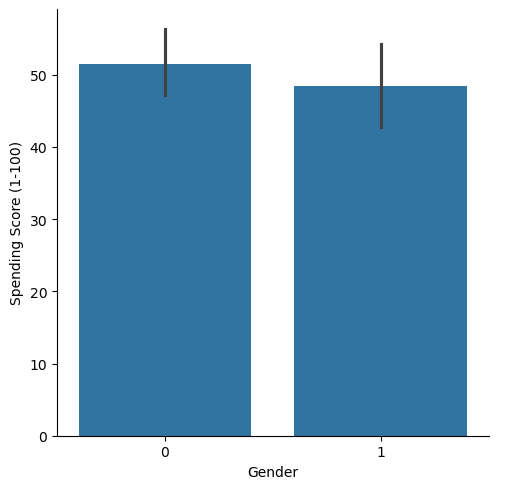

In [23]:
sns.catplot(data,x="Gender",y="Spending Score (1-100)",kind="bar")

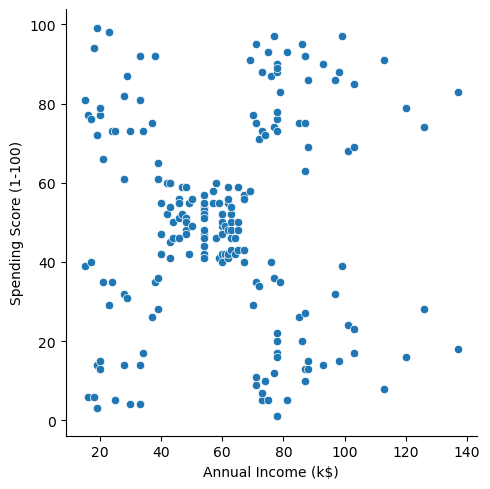

In [24]:
sns.relplot(data,x="Annual Income (k$)",y="Spending Score (1-100)",kind="scatter")

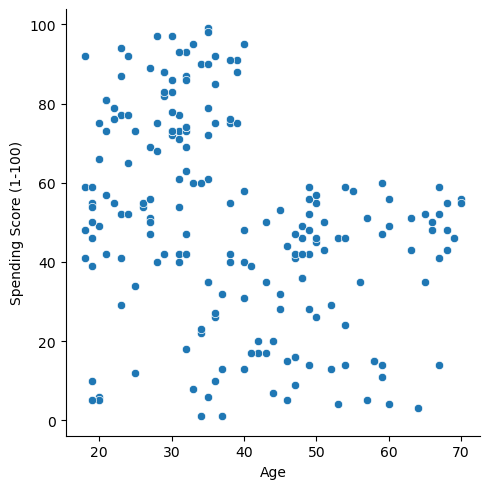

In [25]:
sns.relplot(data,x="Age",y="Spending Score (1-100)",kind="scatter")

## Trani the Model (Clustering)

In [40]:
from sklearn.cluster import DBSCAN,KMeans
from sklearn.preprocessing import StandardScaler

In [41]:
scaler = StandardScaler()

In [42]:
data[data.drop(columns=["CustomerID"]).columns] = scaler.fit_transform(data.drop(columns=["CustomerID"]))

In [43]:
k = []
for i in range(1,20):
    kmeans = KMeans(n_clusters=i).fit(data.drop(columns=["CustomerID"]))
    k.append(kmeans.inertia_)

C:\Users\sajad\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\sajad\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\sajad\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\sajad\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Window

<Axes: >

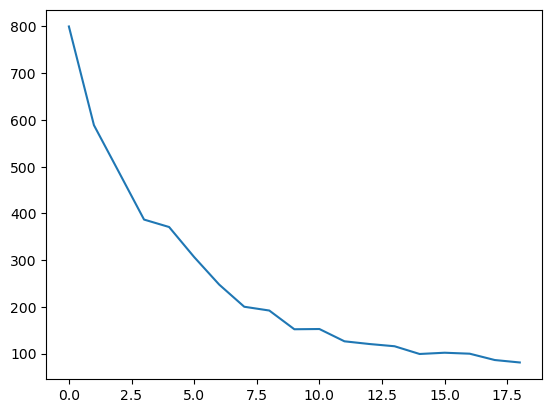

In [50]:
sns.lineplot(x=range(len(k)), y=k)

In [52]:
kmeans = KMeans(n_clusters=6).fit(data.drop(columns=["CustomerID"]))

C:\Users\sajad\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [55]:
data["cluster"] = kmeans.predict(data.drop(columns=["CustomerID"]))

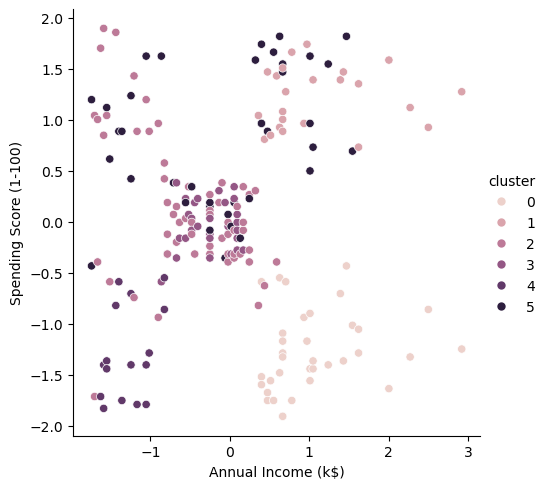

In [56]:
sns.relplot(data,x="Annual Income (k$)",y="Spending Score (1-100)",kind="scatter",hue="cluster")

In [57]:
dbs = DBSCAN().fit(data.drop(columns=["CustomerID"]))

In [59]:
data["dbcluster"] = dbs.labels_

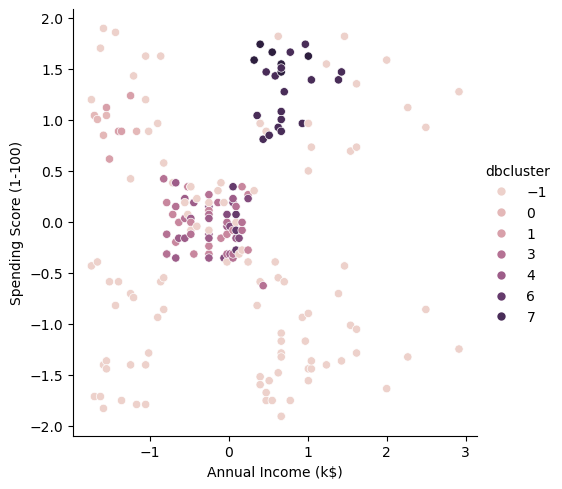

In [60]:
sns.relplot(data,x="Annual Income (k$)",y="Spending Score (1-100)",kind="scatter",hue="dbcluster")

## Send us the Result (Maktabkhoone)